In [27]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from IPython.display import Image
from io import StringIO 
from IPython.display import Image
import graphviz 
import pydotplus
from scipy.optimize import fmin_tnc
from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score 
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import MinMaxScaler,StandardScaler, LabelEncoder
from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.svm import SVC, NuSVC, LinearSVC, OneClassSVM, SVR, NuSVR, LinearSVR
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

In [13]:
data = pd.read_csv('Titanic-Dataset.csv', sep=",")

In [15]:
# Копируем данные
data_processed = data.copy()

In [17]:
#удаление сталбца Cabin - смысла в нем, потому что он нам ничего сказать не может 
# 1. Удаляем Cabin (много пропусков, как вы и сделали)
data_processed = data_processed.drop('Cabin', axis=1)
print(f"После удаления Cabin: {data_processed.columns.tolist()}")

После удаления Cabin: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [19]:
# 2. Кодируем категориальные признаки
data_processed['Sex'] = LabelEncoder().fit_transform(data_processed['Sex']) # male->0, female->1
data_processed['Embarked'] = LabelEncoder().fit_transform(data_processed['Embarked']) # S->0, C->1, Q->2

# 3. Заполняем пропуски в Age медианой (сохраняем больше данных, чем dropna)
data_processed['Age'] = data_processed['Age'].fillna(data_processed['Age'].median())

# 4. Формируем X и y
y = data_processed['Survived']
X = data_processed.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)

In [21]:
# 2. Разделяем выборку
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% данных в тест, 80% в обучение
    random_state=42,      # фиксация для воспроизводимости
    stratify=y            # сохраняет исходное соотношение классов (выжил/не выжил)
)

In [23]:
# Проверка размеров
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (712, 7), y_train: (712,)
X_test:  (179, 7), y_test:  (179,)


In [29]:
def vis_models_quality(array_metric, array_labels, str_header, figsize=(5, 5)):
    fig, ax1 = plt.subplots(figsize=figsize)
    pos = np.arange(len(array_metric))
    rects = ax1.barh(pos, array_metric,
                     align='center',
                     height=0.5, 
                     tick_label=array_labels)
    ax1.set_title(str_header)
    for a,b in zip(pos, array_metric):
        plt.text(0.2, a-0.1, str(round(b,3)), color='white')
    plt.show()

In [43]:
from heamy.estimator import Regressor, Classifier
from heamy.pipeline import ModelsPipeline
from heamy.dataset import Dataset


In [45]:
# Качество отдельных моделей
def val_mae(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    result = mean_absolute_error(y_test, y_pred)
    print(model)
    print('MAE={}'.format(result))

In [47]:
# Точность на отдельных моделях
for model in [
    LinearRegression(),
    DecisionTreeRegressor(),
    RandomForestRegressor(n_estimators=50)
]:
    val_mae(model)
    print('==========================')
    print()

LinearRegression()
MAE=0.30186283361242194

DecisionTreeRegressor()
MAE=0.1852886405959032

RandomForestRegressor(n_estimators=50)
MAE=0.2653893766072537



In [61]:
# Используем библиотеку heamy
# набор данных
dataset = Dataset(X_train, y_train, X_test)

# модели первого уровня
model_tree = Regressor(dataset=dataset, estimator=DecisionTreeRegressor, name='tree')
model_lr = Regressor(dataset=dataset, estimator=LinearRegression, name='lr')
model_rf = Regressor(dataset=dataset, estimator=RandomForestRegressor, parameters={'n_estimators': 50},name='rf')

In [63]:
# Эксперимент 1
# Первый уровень - две модели: дерево и линейная регрессия
# Второй уровень: линейная регрессия

pipeline = ModelsPipeline(model_tree, model_lr)
stack_ds = pipeline.stack(k=10, seed=1)
# модель второго уровня
stacker = Regressor(dataset=stack_ds, estimator=LinearRegression)
results = stacker.validate(k=10,scorer=mean_absolute_error)

Metric: mean_absolute_error
Folds accuracy: [0.24289974327449204, 0.29835214422666223, 0.3482494889152726, 0.23937888330768947, 0.28739013278442976, 0.25984429541796156, 0.25807181451180733, 0.27437669001666865, 0.2733440905179734, 0.2767629222252211]
Mean accuracy: 0.2758670205198178
Standard Deviation: 0.029796973233536642
Variance: 0.0008878596138800991


In [65]:
# Эксперимент 2
# Первый уровень - две модели: дерево и линейная регрессия
# Второй уровень: случайный лес

stacker = Regressor(dataset=stack_ds, estimator=RandomForestRegressor)
results = stacker.validate(k=10,scorer=mean_absolute_error)

Metric: mean_absolute_error
Folds accuracy: [0.22721296296296295, 0.2140277777777778, 0.3171830985915493, 0.24378169014084505, 0.26999999999999996, 0.21456572769953053, 0.26752112676056333, 0.2478169014084507, 0.2871056338028169, 0.24094332662642526]
Mean accuracy: 0.2530158245770922
Standard Deviation: 0.03114599301995192
Variance: 0.0009700728811988937


In [67]:
# Эксперимент 3
# Первый уровень - три модели: дерево, линейная регрессия и случайный лес
# Второй уровень: линейная регрессия
pipeline = ModelsPipeline(model_tree, model_lr, model_rf)
stack_ds3 = pipeline.stack(k=10, seed=1)
# модель второго уровня
stacker = Regressor(dataset=stack_ds3, estimator=LinearRegression)
results = stacker.validate(k=10,scorer=mean_absolute_error)

Metric: mean_absolute_error
Folds accuracy: [0.21793209587100376, 0.2938080296817158, 0.3393931609208016, 0.23276816525473734, 0.27189905457786, 0.24939200751524723, 0.2595194912556505, 0.257237727485601, 0.25383974809782694, 0.25104237750685704]
Mean accuracy: 0.2626831858167301
Standard Deviation: 0.0320401453473815
Variance: 0.001026570913881332


In [69]:
# Эксперимент 4
# Первый уровень - три модели: дерево, линейная регрессия и случайный лес
# Второй уровень: случайный лес
# Результат хуже чем в эксперименте 3
stacker = Regressor(dataset=stack_ds3, estimator=RandomForestRegressor)
results = stacker.validate(k=10,scorer=mean_absolute_error)

Metric: mean_absolute_error
Folds accuracy: [0.1922222222222222, 0.295625, 0.29161971830985917, 0.21990140845070427, 0.2771830985915492, 0.2144929577464789, 0.2600093896713615, 0.25442723004694834, 0.2614483568075117, 0.21362676056338026]
Mean accuracy: 0.2480556142410016
Standard Deviation: 0.03404962349630672
Variance: 0.0011593768602402427


In [91]:
# Результаты
array_labels = ['LR','TREE', 'RF', 'TREE+LR=>LR', 
                'TREE+LR=>RF', 'TREE+LR+RF=>LR', 'TREE+LR+RF=>RF']
array_mae = [0.30186283361242194,  # LR
             0.1852886405959032,   # TREE
             0.2653893766072537,   # RF
             0.2758670205198178,   # Exp 1: TREE+LR=>LR
             0.2758670205198178,   # Exp 2: TREE+LR=>RF
             0.2626831858167301,   # Exp 3: TREE+LR+RF=>LR
             0.2480556142410016]   # Exp 4: TREE+LR+RF=>RF

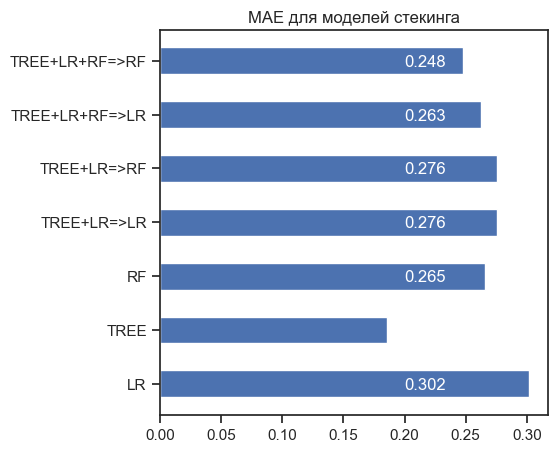

In [93]:
# Визуализация результатов
vis_models_quality(array_mae, array_labels, 'MAE для моделей стекинга')

In [95]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [97]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # два скрытых слоя: 100 и 50 нейронов
    activation='relu',              # функция активации
    solver='adam',                  # оптимизатор
    alpha=0.001,                    # коэффициент регуляризации
    learning_rate='adaptive',       # стратегия обучения
    learning_rate_init=0.001,       # начальная скорость обучения
    max_iter=500,                   # максимальное число итераций
    random_state=42,
    early_stopping=True,            # остановка при отсутствии улучшений
    validation_fraction=0.1,        # доля данных для валидации
    verbose=False
)

In [101]:
# Обучение модели
mlp.fit(X_train_scaled, y_train)

MLPClassifier(alpha=0.001, early_stopping=True, hidden_layer_sizes=(100, 50),
              learning_rate='adaptive', max_iter=500, random_state=42)

In [103]:
# Предсказания и оценка качества
y_pred_train = mlp.predict(X_train_scaled)
y_pred_test = mlp.predict(X_test_scaled)

In [105]:
print("=== Результаты на тренировочной выборке ===")
print(f"Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print("\nClassification Report:")
print(classification_report(y_train, y_pred_train))

print("\n=== Результаты на тестовой выборке ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

=== Результаты на тренировочной выборке ===
Accuracy: 0.8118

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       439
           1       0.84      0.63      0.72       273

    accuracy                           0.81       712
   macro avg       0.82      0.78      0.79       712
weighted avg       0.82      0.81      0.80       712


=== Результаты на тестовой выборке ===
Accuracy: 0.7989

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       110
           1       0.81      0.62      0.70        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179


Confusion Matrix:
[[100  10]
 [ 26  43]]


In [ ]:
#Оцените качество моделей с помощью одной из подходящих для 
#задачи метрик. Сравните качество полученных моделей.
